# Nonlinear OU with colored noise — Markovian embedding of finite-τc noise

**Showcases:** colored (finite-$\tau_c$) noise via **Markovian embedding** (auxiliary OU field). The physical process is driven by exponentially correlated noise $\langle\xi(t)\xi(t')\rangle = (2D/\tau_c)\,e^{-|t-t'|/\tau_c}$, which is **not** white — so the MSR-JD diagrammatics cannot act on it directly. The pipeline's preprocessor rewrites the noise as its own Ornstein–Uhlenbeck field $\xi$ driven by *white* noise; the model then carries an **extra fluctuation field** (`dxi`), and every diagram runs on the enlarged, purely-Markovian system. Run here to **1-loop**.

$$\dot x = -\mu\,x - \varepsilon\,x^3 + \xi,\qquad \dot\xi = -\xi/\tau_c + \sqrt{2D}/\tau_c\,\eta,\qquad \langle\eta\eta\rangle = \delta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file. The source theory declares a **single** physical field $x$ with a colored noise term; the loader's Markovian-embedding preprocessor has already run, so `describe_model` shows the **embedded** system — note the auxiliary field `dxi` (the OU noise process $\xi$) and its response leg `xit` alongside the physical `dx`. That extra field *is* the embedding.

In [2]:
THEORY = 'ou_quartic_colored'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
# The embedding is visible in the field list: 'dx' is the physical
# fluctuation, 'dxi' is the auxiliary OU noise field added to Markovianize
# the colored drive.
print('\nphysical fields after embedding:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Quartic Colored
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable; xi — auxiliary OU noise (Markovian embedding of colored CGF on x)
Response fields: xt, xit
Parameters     :
    mu = 0.1  (real)
    eps = 0.1  (positive)
    D = 1.0  (positive)
    tauc = 1.0  (positive)
Mean-field saddle (solved by the pipeline): xstar, xistar
Governing eqn  : (Dt+mu)*x = -eps*x^3
Suggested run  : k=2, max_ell=0

physical fields after embedding: ['dx', 'dxi']


## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant), now on the embedded white-noise system. We request the **physical** autocorrelator $C_{xx}(\tau)=\langle x(0)\,x(\tau)\rangle$ via `external_fields=[('dx',1),('dx',1)]` — both external legs on the physical field `dx`, never the auxiliary `dxi`. The plot is the **theory only** — the simulation is added in §3.

Parameters sit in the mildly-perturbative single-well regime ($\mu>0$, saddle $x^*=0$). We keep $\mu\,\tau_c\neq 1$: the embedded propagator has poles at $\mu$ and $1/\tau_c$, and the v1 preprocessor needs them distinct (the exact $\mu=1/\tau_c$ degeneracy is a double pole, not yet handled).

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,                          # C_xx(τ), tree + 1-loop
    external_fields=[('dx', 1), ('dx', 1)],  # physical field autocorrelator
    parameters={'mu': 1.0, 'eps': 0.02, 'D': 1.0, 'tauc': 0.5},
    tau_grid=(-8.0, 8.0, 33),
    parallel=False,                          # serial (no fork in a notebook)
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   kpoint_base_lags=[0.0, 0.0],  # k≥3 temporal: fix the non-swept legs (slices cross here)
#   kpoint_full_grid=True,        # k≥3 temporal: full (k−1)-D tensor C(τ₁,…) vs axis slices
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : 'OU Quartic Colored'
k      : 2    max_ell : 1
fields : ['dx', 'dxi']   spatial_dim : 0


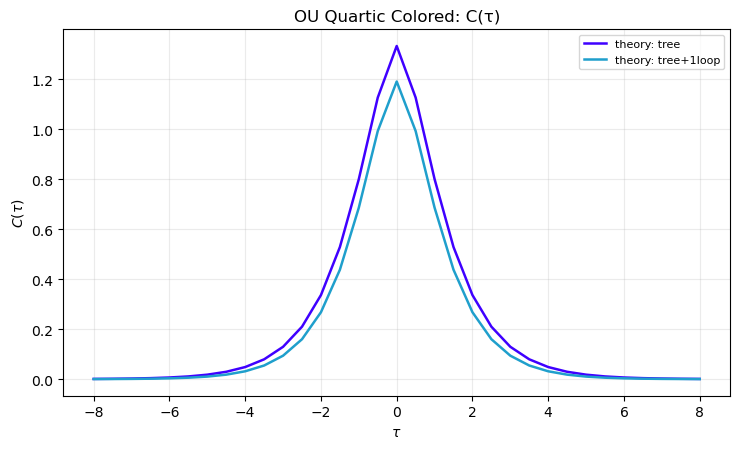

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct Euler–Maruyama integration of the **colored-noise SDE** — written from scratch, no reference to the diagrammatics. The simulator generates the colored drive with its *own* exact-discretized OU auxiliary inside the loop (the same physical content the preprocessor embeds), integrates the physical field $x$, and we estimate the connected $C_{xx}(\tau)$. Overlaying it on the pipeline curve is the validation.

sim took 2.2s  (3 runs × T=3e+05)
C_xx(0):  tree = 1.3333   tree+1-loop = 1.1911   sim = 1.1845 ± 0.0026


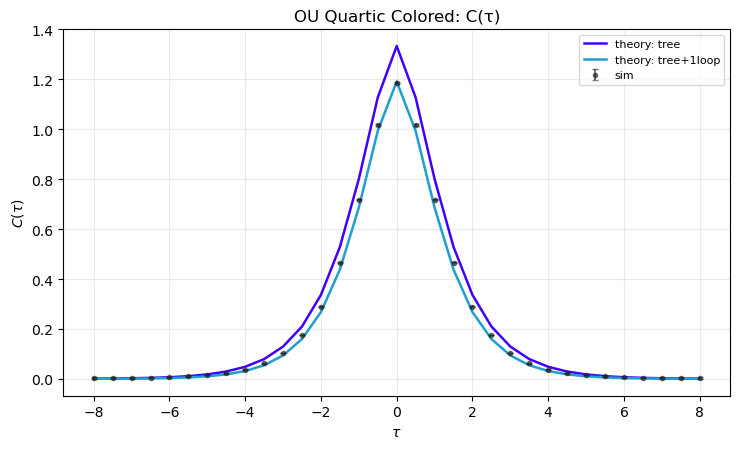

In [5]:
# Independent SDE simulation (Euler–Maruyama; colored noise from an
# exact-discretized OU auxiliary INSIDE the simulator) — NOT the pipeline.
from models.ou_langevin_sim_numba import sim_ou_quartic_colored_numba
from models.cumulant_estimator import estimate_kpoint_slices
fp = res['_resolved']['parameters']       # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params
# are Sage ring elements, which numba's njit cannot type.
mu   = float(fp['mu']); eps = float(fp['eps'])
D    = float(fp['D']);  tauc = float(fp['tauc'])

# Discretization (dt ≪ tauc for the x-step; OU drive is exact at any dt).
# Force plain Python int/float on every scalar — under the Sage kernel bare
# literals are Sage ring elements that numba's njit cannot type.
dt_sim, dt_bin = float(0.01), float(0.5)
T_sim          = float(3.0e5)              # trimmed for a ~1-min run
N_RUNS         = int(3)
tau_max        = float(np.max(np.abs(res['tau_grid'])))
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)
x_init         = float(0.0)

# k-aware: estimate the k−1 cumulant slices that match res['C_tau_slices']
# and dd.plot_cumulant's k≥3 panels.  ou_quartic_colored is a SINGLE
# physical field x, so every external leg is the same 'dv' field.
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]   # base lags -> bins
pop_indices = [0]*k
field_types = ['dv']*k

_ = sim_ou_quartic_colored_numba(int(1000), dt_sim, mu, eps, D, tauc,
                                 x_init, bin_size_steps, int(100),
                                 int(0))                    # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    x_bins = sim_ou_quartic_colored_numba(
        n_steps, dt_sim, mu, eps, D, tauc, x_init,
        bin_size_steps, n_bins, int(rng_base + r))        # shape (1, n_bins)
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=x_bins)           # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)                  # (N_RUNS, k-1, n_tau)
C_sim = C_arr.mean(axis=0)                # (k-1, n_tau)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}   # 2-D: one row per slice
print('sim took %.1fs  (%d runs × T=%.0g)' % (time.perf_counter() - t0,
      N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xx(0):  tree = %.4f   tree+1-loop = %.4f   sim = %.4f ± %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The colored (finite-$\tau_c$) drive is **not** white, so it cannot enter the MSR-JD machinery directly. The Markovian-embedding preprocessor rewrites it as an auxiliary OU field — visible as the extra `dxi` field in `describe_model` — and the entire diagrammatics then runs on the enlarged **white-noise** system. Asking for `('dx','dx')` recovers the physical autocorrelator $C_{xx}(\tau)$. The cubic nonlinearity suppresses the equal-time variance below the linear (tree) value; the 1-loop self-energy captures that shift, moving the theory from the tree estimate toward the direct colored-noise simulation (here from $\sim$+10% at tree to within a couple percent at tree+1-loop). The only thing that changed versus a white-noise OU run is the noise kernel — the embedding is automatic.